## Concluzii EDA (Exploratory Data Analysis)
1. TotalCharges e string, trebuie convertit
2. 27% churn rate — dezechilibru de clase
3. Clienții noi (tenure mic) pleacă mai des
4. Clienții care plătesc mult pleacă mai des
5. Tenure și TotalCharges sunt foarte corelate (0.83)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/Telco-Customer-Churn.csv',sep=',')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:

print("Shape:", df.shape)
df.info()


df.describe()


df.describe(include='object')

Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

/var/folders/2b/lc04rt597mzfjm97dlt5by740000gn/T/ipykernel_71194/2810196508.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [38]:
missing = (df.isnull().sum() / len(df) * 100).round(2)
print("Valori lipsa (%):")
print(missing[missing > 0].sort_values(ascending=False))
if missing.sum() == 0:
    print("Nu sunt valori lipsa aparente (dar pot exista spatii ascunse!)")


Valori lipsa (%):
Series([], dtype: float64)
Nu sunt valori lipsa aparente (dar pot exista spatii ascunse!)


In [39]:

for c in df.columns:
    print(f"{c}: {df[c].nunique()} valori unice | dtype: {df[c].dtype}")

customerID: 7043 valori unice | dtype: str
gender: 2 valori unice | dtype: str
SeniorCitizen: 2 valori unice | dtype: int64
Partner: 2 valori unice | dtype: str
Dependents: 2 valori unice | dtype: str
tenure: 73 valori unice | dtype: int64
PhoneService: 2 valori unice | dtype: str
MultipleLines: 3 valori unice | dtype: str
InternetService: 3 valori unice | dtype: str
OnlineSecurity: 3 valori unice | dtype: str
OnlineBackup: 3 valori unice | dtype: str
DeviceProtection: 3 valori unice | dtype: str
TechSupport: 3 valori unice | dtype: str
StreamingTV: 3 valori unice | dtype: str
StreamingMovies: 3 valori unice | dtype: str
Contract: 3 valori unice | dtype: str
PaperlessBilling: 2 valori unice | dtype: str
PaymentMethod: 4 valori unice | dtype: str
MonthlyCharges: 1585 valori unice | dtype: float64
TotalCharges: 6531 valori unice | dtype: str
Churn: 2 valori unice | dtype: str


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


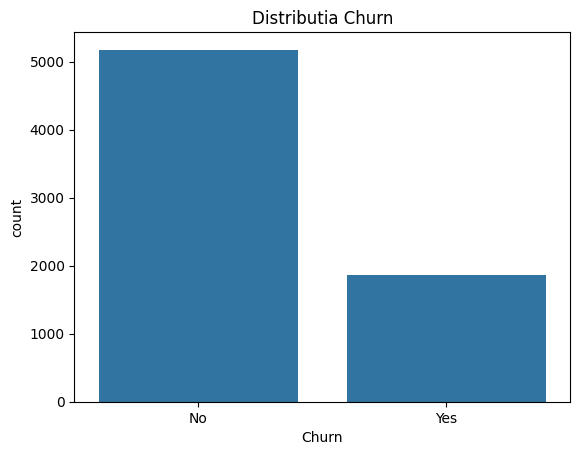

In [40]:

print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

sns.countplot(data=df, x='Churn')
plt.title('Distributia Churn')
plt.show()


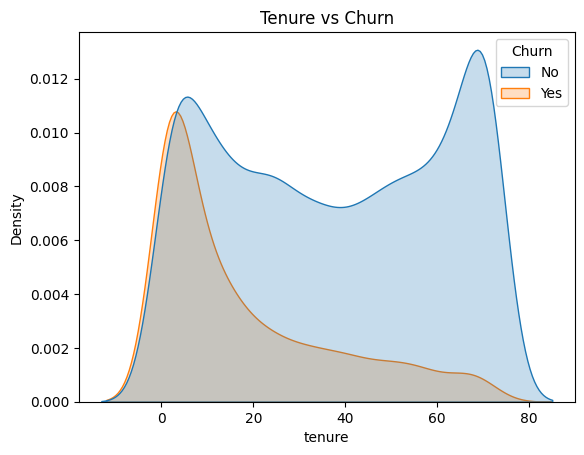

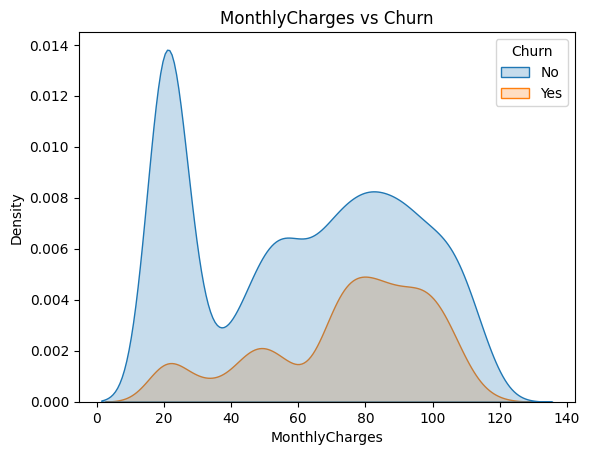

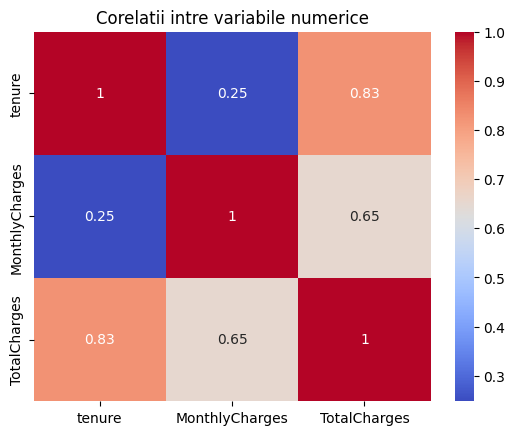

Randuri duplicate: 0


In [ ]:

sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True)
plt.title('Tenure vs Churn')
plt.show()


sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)
plt.title('MonthlyCharges vs Churn')
plt.show()


temp = df.copy()
temp['TotalCharges'] = pd.to_numeric(temp['TotalCharges'], errors='coerce')
sns.heatmap(temp[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm')
plt.title('Corelatii intre variabile numerice')
plt.show()


print(f"Randuri duplicate: {df.duplicated().sum()}")